# CMSE 381 Final Project Template

#### CMSE 381 Final Project
### &#9989; Group members: Mint Menakanit, Brian Kim
### &#9989; Section_001
#### &#9989; Date

# ___Student Exam Score___

## Background and Motivation

_(Provide context for the problem.  **Clearly state the question(s) you set
out to answer.**)_

Academic success is influenced by many different factors, including study habits, attendance, family background, school environment, and access to resources. Understanding which of these factors are most strongly related to student performance is important because it can help explain why some students perform better than others and can also help identify students who may need additional support.

In this project, we use the Student Performance Factors dataset to study what drives exam performance. The dataset contains 19 predictors related to academic behavior, personal habits, and background characteristics, along with each student’s exam score. Our goal is to use methods learned in class to better understand which variables matter most and how well student performance can be predicted.

We focus on both regression and classification analysis. Regression allows us to predict a student’s exact exam score, while classification allows us to group students into broader performance categories such as low, medium, and high performers. Looking at the problem from both perspectives gives a more complete picture of academic success.

The main questions we set out to answer in this report are:

1. Can we accurately predict a student’s exam score using the 19 available predictors, and which variables are the most important?
2. Can we accurately classify students into broader performance groups (low, medium, and high) based on these predictors?
3. Do lasso and ridge regression outperform OLS and effectively produce auto features selection?
4. Can we compress the predictor space into a small number of principal components without losing predictive power and what do those components represent?

By answering these questions, we hope to better understand both the prediction and interpretation of student performance, while also comparing several statistical learning methods covered in class.
Understanding what factors drive academic success.

## Methodology
_(How did you go about answering your question(s)? You should wrote some code here to demonstrate what the data is like and how in principle your method works. You can leave the variations of the related to specific results to the results section.)_

To answer our project questions, we first prepared the dataset so it could be used in multiple statistical learning methods. We then applied classification, regression, regularization, and dimension reduction techniques to study student performance from different perspectives.

### Data loading

We used the Student Performance Factors dataset, which contains 6607 observations, 19 predictor variables, and 1 response variable (Exam_Score).

### Data cleaning and preprocessing

We checked for missing values and found them in Teacher_Quality, Parental_Education_Level, and Distance_from_Home. We filled these missing values using the mode so that all observations could be kept. We then converted categorical variables into numeric form. Ordinal variables were mapped to ordered numbers, and binary variables were encoded as 0/1. For methods sensitive to scale, such as logistic regression, ridge, lasso, and PCA, we standardized the predictors using StandardScaler.

### Classification

For classification, we converted Exam_Score into three groups: Low, Medium, and High using quantile-based cutoffs. We first fit a multinomial logistic regression model as a baseline because it is simple and interpretable. We evaluated its performance using a training/test split and 10-fold cross-validation, with metrics including accuracy, macro F1-score, and the confusion matrix.

### Regression

For regression, we treated Exam_Score as a continuous response and fit an OLS multiple linear regression model using all 19 predictors. We evaluated the model with K-fold cross-validation using R-squared and RMSE, and we also examined coefficients and diagnostic plots.

### Ridge and Lasso

To improve on OLS, we fit ridge and lasso regression models. We used cross-validation to choose the regularization parameter. Ridge shrinks coefficients toward zero, while lasso can shrink some coefficients exactly to zero, which provides automatic feature selection. We compared both methods to OLS based on predictive performance and interpretability.

### PCA

We used principal component analysis to reduce the predictor space into a smaller number of components. After standardizing the predictors, we examined the explained variance and evaluated how many components were needed to retain most of the information. This allowed us to study whether we could simplify the data without losing much predictive power.

In [3]:
# you may want to import some modules here
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# regression
from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, Ridge, Lasso

#classification 
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)
# PCA
from sklearn.decomposition import PCA

# CV and metrics
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

np.random.seed(381)
sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

### Data
_(Describe the data you are using. What variables are you using? What they mean? Why did you choose them?)_

In [4]:
# you may want to write some code to see what the data looks like
df = pd.read_csv("Student_Performance_Factors.csv")
print(df.shape)
df.head()

# 6607 dataset
# 20 columns : 19 features 1 target (exam score)

(6607, 20)


,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [ ]:
# you may need some code here to adjust the format or organization of your data so that they can be used for the model

In [5]:
# check for null value
print(df.isnull().sum()[df.isnull().sum() > 0])

Teacher_Quality             78
Parental_Education_Level    90
Distance_from_Home          67
dtype: int64


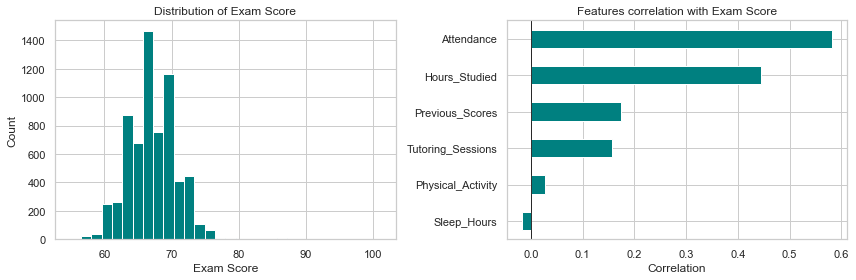

Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Exam_Score"], bins = 30, edgecolor = "white", color = "teal")
axes[0].set_xlabel("Exam Score")
axes[0].set_ylabel("Count")
axes[0].set_title("Distribution of Exam Score")

num_cols = df.select_dtypes(include = "number").columns
corr = df[num_cols].corr()["Exam_Score"].drop("Exam_Score").sort_values()
corr.plot(kind = "barh", ax = axes[1], color = "teal")
axes[1].set_title("Features correlation with Exam Score")
axes[1].set_xlabel("Correlation")
axes[1].axvline(0, color = "black", linewidth = 0.8)

plt.tight_layout()
plt.show()

print(corr.sort_values(ascending = False))

### Models for classification _(if applicable)_
_(What models will you be using for classification? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

In [16]:
#Creating 3 class target
df_class = df_1.copy()
q1 = df_class["Exam_Score"].quantile(1/3)
q2 = df_class["Exam_Score"].quantile(2/3)

def score_to_class(x):
    if x <= q1:
        return "Low"
    elif x <= q2:
        return "Medium"
    else:
        return "High"

df_class["Score_Class"] = df_class["Exam_Score"].apply(score_to_class)

print("Class counts:")
print(df_class["Score_Class"].value_counts())

Class counts:
Low       2882
Medium    2100
High      1625
Name: Score_Class, dtype: int64


In [10]:
# Feature matrix and split
X_class_raw = df_class[feature_cols].values.astype(float)
y_class = df_class["Score_Class"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_class_raw,
    y_class,
    test_size=0.2,
    random_state=381,
    stratify=y_class
)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (5285, 19)
Testing set shape: (1322, 19)


In [11]:
# Multinomial Logistic Regression
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("logit", LogisticRegression(
        multi_class="multinomial",
        max_iter=2000,
        random_state=381
    ))
])

logit_pipe.fit(X_train, y_train)
y_pred_logit = logit_pipe.predict(X_test)

logit_acc = accuracy_score(y_test, y_pred_logit)
logit_f1 = f1_score(y_test, y_pred_logit, average="macro")

print("Logistic Regression Results")
print("Test Accuracy:", round(logit_acc, 4))
print("Macro F1:", round(logit_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_logit))

Logistic Regression Results
Test Accuracy: 0.966
Macro F1: 0.9646

Classification Report:
              precision    recall  f1-score   support

        High       0.97      0.95      0.96       325
         Low       0.97      0.98      0.98       577
      Medium       0.96      0.95      0.95       420

    accuracy                           0.97      1322
   macro avg       0.97      0.96      0.96      1322
weighted avg       0.97      0.97      0.97      1322



In [12]:
# Logistic Regression Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=381)
logit_cv_scores = cross_val_score(
    logit_pipe,
    X_class_raw,
    y_class,
    cv=cv,
    scoring="accuracy"
)

print("10-fold CV Accuracy (Logistic):", round(logit_cv_scores.mean(), 4))

10-fold CV Accuracy (Logistic): 0.9664


In [17]:
# Random Forest with GridSearchCV
rf = RandomForestClassifier(random_state=381)

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 5, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

rf_grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

best_rf = rf_grid.best_estimator_
y_pred_rf = best_rf.predict(X_test)

rf_acc = accuracy_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf, average="macro")

print("Best Random Forest Parameters:")
print(rf_grid.best_params_)

print("\nRandom Forest Results")
print("Test Accuracy:", round(rf_acc, 4))
print("Macro F1:", round(rf_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("Best CV Accuracy (Random Forest):", round(rf_grid.best_score_, 4))

Best Random Forest Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 400}

Random Forest Results
Test Accuracy: 0.8283
Macro F1: 0.8206

Classification Report:
              precision    recall  f1-score   support

        High       0.91      0.75      0.82       325
         Low       0.87      0.91      0.89       577
      Medium       0.72      0.78      0.75       420

    accuracy                           0.83      1322
   macro avg       0.84      0.81      0.82      1322
weighted avg       0.83      0.83      0.83      1322

Best CV Accuracy (Random Forest): 0.8314


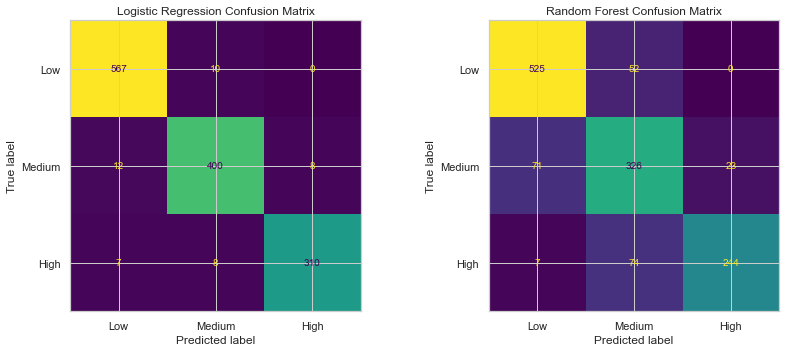

In [18]:
# Confusion Matrices

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_logit = confusion_matrix(y_test, y_pred_logit, labels=["Low", "Medium", "High"])
disp1 = ConfusionMatrixDisplay(
    confusion_matrix=cm_logit,
    display_labels=["Low", "Medium", "High"]
)
disp1.plot(ax=axes[0], colorbar=False)
axes[0].set_title("Logistic Regression Confusion Matrix")

cm_rf = confusion_matrix(y_test, y_pred_rf, labels=["Low", "Medium", "High"])
disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Low", "Medium", "High"]
)
disp2.plot(ax=axes[1], colorbar=False)
axes[1].set_title("Random Forest Confusion Matrix")

plt.tight_layout()
plt.savefig("fig_classification_confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

### Models for regression _(if applicable)_
_(What models will you be using for regression? Why did you choose to use them? What questions would you answer with them? How would you evaluate if each model? What cross-validation method did you use?)_

### Multiple linear regression 
We use ordinary least squares as our baseline since it minimizes residual sum of squares with no penalty term.
By evaluating with 10 fold cross validation, we can interpret coefficients with full scaled feature matrix as input.

In [15]:
# you may add some code here to show how the model works in principle
kf = KFold(n_splits = 10, shuffle = True, random_state = 381)
ols = LinearRegression()

cv_r2  = cross_val_score(ols, X, y, cv = kf, scoring = "r2")
cv_mse = cross_val_score(ols, X, y, cv = kf, scoring = "neg_mean_squared_error")
cv_rmse = np.sqrt(-cv_mse)

print("Mean R squared :", cv_r2.mean())
print("Mean RMSE :", cv_rmse.mean())

Mean R squared : 0.7320835002853239
Mean RMSE : 2.0007878971095545


In [17]:
# Fit on full data
ols.fit(X, y)
coef_df = pd.DataFrame({ "Feature": feature_cols,
                         "Coefficient": ols.coef_
                       }).sort_values("Coefficient", key = abs, ascending = False)
print(coef_df.head(10).to_string(index = False))

                 Feature  Coefficient
              Attendance     2.296538
           Hours_Studied     1.766396
     Access_to_Resources     0.716066
         Previous_Scores     0.704120
    Parental_Involvement     0.692732
       Tutoring_Sessions     0.611948
           Family_Income     0.394808
          Peer_Influence     0.388243
Parental_Education_Level     0.379967
        Motivation_Level     0.368391


In [18]:
# Fit residual
y_pred_ols = ols.predict(X)
residuals = y - y_pred_ols

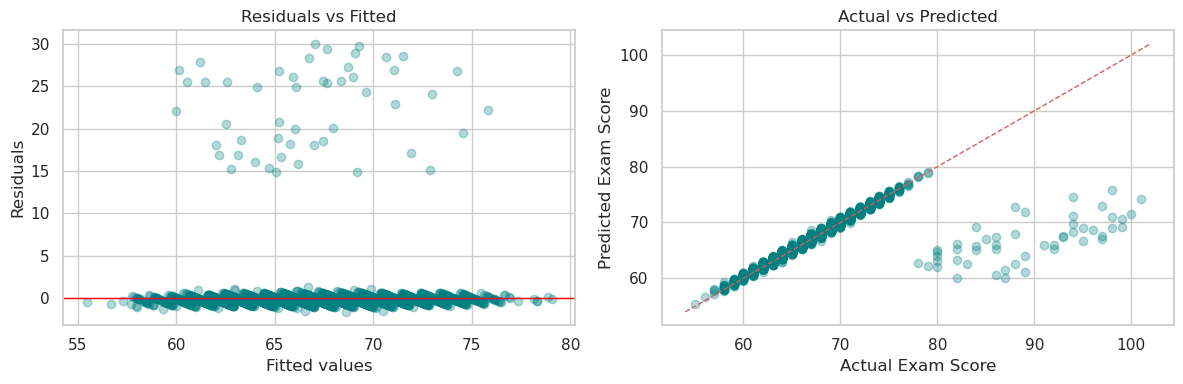

In [21]:
# Residual Graph
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_ols, residuals, alpha = 0.3, color = "teal")
axes[0].axhline(0, color = "red", linewidth = 1)
axes[0].set_xlabel("Fitted values")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Fitted")

axes[1].scatter(y, y_pred_ols, alpha = 0.3, color = "teal")
lims = [min(y.min(), y_pred_ols.min()) - 1, max(y.max(), y_pred_ols.max()) + 1]
axes[1].plot(lims, lims, "r--", linewidth = 1)
axes[1].set_xlabel("Actual Exam Score")
axes[1].set_ylabel("Predicted Exam Score")
axes[1].set_title("Actual vs Predicted")

plt.tight_layout()
plt.show()

### Ridge and Lasso Regression  
Now we use RidgeCV and LassoCV from sklearn which would internally search over grid of alpha values using 10 fold cross validation and select alpha that minimize cross validation MSE which would improve our model since OLS can overfit when predictors are correlated or when many have small true effects.

#### Ridge Regression
Ridge with cross validation alpha then re-evaluated with k-folds to get R squared and RMSE. 

In [25]:
# Ridge
alphas = np.logspace(-3, 4, 200)

ridge_cv = RidgeCV(alphas = alphas, cv = 10, scoring = "neg_mean_squared_error")
ridge_cv.fit(X, y)
best_alpha_ridge = ridge_cv.alpha_

ridge_fixed = Ridge(alpha = best_alpha_ridge)
r2_ridge  = cross_val_score(ridge_fixed, X, y, cv = kf, scoring = "r2")
mse_ridge = cross_val_score(ridge_fixed, X, y, cv = kf, scoring = "neg_mean_squared_error")
rmse_ridge = np.sqrt(-mse_ridge)

print("Best alpha :", best_alpha_ridge)
print("Mean R squared :", r2_ridge.mean())
print("Mean RMSE :", rmse_ridge.mean())

Best alpha : 8.703591361485167
Mean R squared : 0.7320887565248518
Mean RMSE : 2.0007790613346


#### Lasso Regression
Lasso with cross validation alpha then inspect which features lasso featured out.

In [26]:
# Lasso
lasso_cv = LassoCV(alphas = alphas, cv = 10, max_iter = 10000, random_state = 381)
lasso_cv.fit(X, y)
best_alpha_lasso = lasso_cv.alpha_

lasso_fixed = Lasso(alpha = best_alpha_lasso, max_iter = 10000)
r2_lasso  = cross_val_score(lasso_fixed, X, y, cv = kf, scoring = "r2")
mse_lasso = cross_val_score(lasso_fixed, X, y, cv = kf, scoring = "neg_mean_squared_error")
rmse_lasso = np.sqrt(-mse_lasso)

print("Best alpha :", best_alpha_lasso)
print("Mean R squared :", r2_lasso.mean())
print("Mean RMSE :", rmse_lasso.mean())

Best alpha : 0.004659525668664682
Mean R squared : 0.7321080231447741
Mean RMSE : 2.0007197703060524


In [33]:
# Feature selection
lasso_fixed.fit(X, y)
lasso_coef_df = pd.DataFrame({"Feature": feature_cols,
                              "Lasso_Coef": lasso_fixed.coef_
                             }).sort_values("Lasso_Coef", key = abs, ascending = False)

zeroed = lasso_coef_df[lasso_coef_df["Lasso_Coef"] == 0]["Feature"].tolist()
retained = lasso_coef_df[lasso_coef_df["Lasso_Coef"] != 0]

print("Total feature zeroed out", len(zeroed), ":", zeroed)
print("Retained feature by rank :\n", retained.head(10).to_string(index = False))

Total feature zeroed out 1 : ['Sleep_Hours']
Retained feature by rank :
                  Feature  Lasso_Coef
              Attendance    2.291571
           Hours_Studied    1.761593
     Access_to_Resources    0.710986
         Previous_Scores    0.699328
    Parental_Involvement    0.687736
       Tutoring_Sessions    0.607398
           Family_Income    0.390127
          Peer_Influence    0.383635
Parental_Education_Level    0.375060
        Motivation_Level    0.363698


### Other methods used _(if applicable)_

_(If this is a preprocessing step to prepare your data for regression or classification models, you should put this subsection before your explanation for the regression or classification models.)_

_(What method did you use otherwise? Why did you choose to use them? What questions would you answer with them? How would you evaluate the results? What cross-validation method did you use when applicable?)_

In [10]:
# fill out null value
df_1 = df.copy()
for col in ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]:
    df_1[col] = df[col].fillna(df[col].mode()[0])
print(df_1.isnull().sum()[df_1.isnull().sum() > 0])

Series([], dtype: int64)


In [11]:
# Encode category to binary
ordinal_maps = {
    "Parental_Involvement":    {"Low": 0, "Medium": 1, "High": 2},
    "Access_to_Resources":     {"Low": 0, "Medium": 1, "High": 2},
    "Motivation_Level":        {"Low": 0, "Medium": 1, "High": 2},
    "Family_Income":           {"Low": 0, "Medium": 1, "High": 2},
    "Teacher_Quality":         {"Low": 0, "Medium": 1, "High": 2},
    "Parental_Education_Level":{"High School": 0, "College": 1, "Postgraduate": 2},
    "Distance_from_Home":      {"Near": 0, "Moderate": 1, "Far": 2},
    "Peer_Influence":          {"Negative": 0, "Neutral": 1, "Positive": 2},
}
for col, mapping in ordinal_maps.items():
    df_1[col] = df_1[col].map(mapping)

binary_maps = {
    "Extracurricular_Activities": {"No": 0, "Yes": 1},
    "Internet_Access":            {"No": 0, "Yes": 1},
    "School_Type":                {"Public": 0, "Private": 1},
    "Learning_Disabilities":      {"No": 0, "Yes": 1},
    "Gender":                     {"Male": 0, "Female": 1},
}
for col, mapping in binary_maps.items():
    df_1[col] = df_1[col].map(mapping)

In [12]:
# Build X and y
feature_cols = [c for c in df_1.columns if c != "Exam_Score"]
X_raw = df_1[feature_cols].values.astype(float)
y = df_1["Exam_Score"].values.astype(float)

scaler = StandardScaler()
X = scaler.fit_transform(X_raw)

print(X.shape, y.shape)

(6607, 19) (6607,)


In [ ]:
# you may add some code here to show how the method works in principle

# you may add some code here to show how the model works in principle

## Results

_(What did you find when you carried out your methods? Some of your code related to
presenting results/figures/data may be replicated from the methods section or may only be present in
this section. All of the plots that you plan on using for your presentation should be present in this
section)_

### classification results
_(What are you trying to do here?)_

For the classification part of the project, we wanted to determine whether students could be accurately grouped into broader performance categories based on the 19 available predictors. Instead of predicting the exact exam score, we converted Exam_Score into three categories: Low, Medium, and High using quantile-based cutoffs.

After creating these three classes, we built a classification dataset using the same cleaned and encoded predictors from the preprocessing section. We then split the data into training and testing sets using an 80/20 split with stratification so that the class proportions remained similar in both sets.

We first fit a multinomial logistic regression model as a baseline classifier because it is simple and interpretable. We evaluated this model using test accuracy, macro F1-score, a classification report, and 10-fold stratified cross-validation. We then fit a random forest classifier and tuned its hyperparameters using GridSearchCV so that we could compare the baseline model to a more flexible nonlinear model.

_(How do you interpret what you see?)_

_(What are you doing next?)_

The classification results show that student performance groups can be predicted very accurately from the available predictors. The multinomial logistic regression model performed best, achieving a test accuracy of 0.9660, a macro F1-score of 0.9646, and a 10-fold cross-validated accuracy of 0.9664. This means the model correctly classified about 96.6% of students into the Low, Medium, and High groups, and the close agreement between test accuracy and cross-validated accuracy suggests that the model generalizes well.

The logistic regression model also performed strongly across all three categories, with especially high performance for the Low group. In contrast, the random forest model performed worse, with a test accuracy of 0.8283 and a macro F1-score of 0.8206. The confusion matrices show that random forest made more mistakes, especially between the Medium and High groups.

Overall, these results suggest that the relationship between the predictors and student performance groups is captured very well by a relatively simple linear classifier. Next, we move to the regression analysis, where we predict the exact exam score and compare OLS, ridge, and lasso models.

### regression results
_(What are you trying to do here?)_

For the regression part of the project, we wanted to predict a student’s exact exam score using the 19 available predictors. Unlike the classification section, where we grouped students into broader categories, regression lets us estimate the actual numeric value of Exam_Score.

To do this, we fit an OLS multiple linear regression model using all predictors. Before fitting the model, we used the cleaned and encoded dataset from the preprocessing section, where missing values were filled and categorical variables were converted into numeric form. We then standardized the predictors and evaluated the model using 10-fold cross-validation. Our main performance measures were R-squared and root mean squared error. After fitting the model, we also examined the estimated coefficients and created diagnostic plots such as residuals vs fitted values and actual vs predicted values to better understand model performance.

_(How do you interpret what you see?)_

_(What are you doing next?)_

The regression results show that the predictors explain a substantial amount of variation in exam scores. The OLS model achieved a mean cross-validated R-squared of 0.7321 and a mean RMSE of 2.0008, which means the model explains about 73.2% of the variation in exam score and typically predicts within about 2 points of the true score. This suggests that the model fits the data well and provides reasonably accurate score predictions.

Looking at the coefficients, the strongest predictors were Attendance (2.2965) and Hours_Studied (1.7664), followed by Access_to_Resources (0.7161), Previous_Scores (0.7041), Parental_Involvement (0.6927), and Tutoring_Sessions (0.6119). These results suggest that attendance and study behavior are the most important factors associated with higher exam performance in this dataset. 

The diagnostic plots also support that the model performs reasonably well, since the predicted values track the actual scores fairly closely. Next, we compare OLS to ridge and lasso regression to see whether regularization can improve predictive performance and whether lasso can reduce the number of predictors through automatic feature selection.

### other results
_(What are you trying to do here?)_

In [ ]:
# how did you do it

_(How do you interpret what you see?)_

_(What are you doing next?)_

In [ ]:
# how did you do it (etc. etc.)

## Discussion and Conclusion

_(What did you learn from your results? What obstacles did you run into? What would you do differently next time? Clearly provide quantitative answers to your question(s)?  At least one of your questions should be answered with numbers.  That is, it is not sufficient to answer "yes" or "no", but rather to say something quantitative such as variable 1 increased roughly 10% for every 1 year increase in variable 2.)_

### discussion on the classification results
The classification analysis showed that student performance groups can be predicted very accurately using the 19 available predictors. The strongest model was the multinomial logistic regression, which achieved a test accuracy of 0.9660, a macro F1-score of 0.9646, and a 10-fold cross-validated accuracy of 0.9664. Since the test accuracy and cross-validated accuracy are almost identical, this suggests that the model is stable and generalizes well to new data.

One important thing we learned is that students can be separated into Low, Medium, and High performance groups with a high level of precision. The logistic regression model correctly classified about 96.6% of students overall. It performed especially well on the Low group, with a recall of 0.98, meaning it correctly identified 98% of lower-performing students. This is useful because identifying lower-performing students early could help schools target interventions such as tutoring or attendance support.

The random forest model performed worse than logistic regression, with a test accuracy of 0.8283, a macro F1-score of 0.8206, and a cross-validated accuracy of 0.8314. This means logistic regression outperformed random forest by about 13.8 percentage points in test accuracy. The random forest made more mistakes, especially between the Medium and High groups, which suggests that the simpler logistic regression model was actually better suited for this classification problem.

One obstacle we ran into is that the dataset did not come with natural class labels, so we had to create them ourselves by converting the continuous exam score into three categories using quantile-based cutoffs. Because of this, the results depend somewhat on how those cutoffs were chosen. Another limitation is that categorical variables were encoded numerically, which may simplify some relationships in the original data.

If we were to improve this part of the project in the future, we could try other classification methods such as support vector machines or k-nearest neighbors, or test different ways of defining the performance groups. We could also compare ordinal classification methods since the three classes have a natural order. Overall, the classification results clearly answer one of our project questions: yes, students can be classified into broader performance groups very accurately, with the best model reaching about 96.6% accuracy.

### discussion on the regression results

### discussion on the other results

### conclusion and future steps
Overall, our results show that student performance can be predicted effectively using the 19 available predictors. The classification analysis showed that students could be grouped into Low, Medium, and High performance levels with very high accuracy, while the regression analysis helped estimate exact exam scores and identify the most important variables. Across the models, factors such as attendance, hours studied, and previous scores appeared to play the strongest role in predicting student outcomes.

In the future, we could improve this project by testing additional models, exploring different ways to define the performance groups, and comparing other encoding methods for the categorical variables. We could also study whether fewer predictors or principal components can achieve similar predictive performance. Overall, this project shows that statistical learning methods can be useful both for predicting academic success and for understanding which factors matter most.

## Author contribution

_(Please describe the contribution of each member of group)._

## References

_(List the source(s) for any data and/or literature cited in your project.  Ideally, this should be formatted using a formal citation format (MLA or APA or other, your choice!).   Multiple free online citation generators are available such as <a href="http://www.easybib.com/style">http://www.easybib.com/style</a>. **Important:** if you use **any** code that you find on the internet for your project you **must** cite it or you risk losing most/all of the points for you project.)_